# 24 - Capstone: End-to-End from Raw Data to Witness

Welcome to the Capstone project of the `pySurgery` tutorial series! In this final notebook, we tie together everything we have learned—from the foundations of exact linear algebra to the heights of the Surgery Exact Sequence.

We will execute a complete "Raw Data to Decision" pipeline: starting with an unorganized point cloud in high-dimensional space and ending with a mathematically rigorous **Homeomorphism Witness** that classifies the underlying manifold.

## The Capstone Workflow
1. **Raw Data Acquisition**: Generate or import a noisy point cloud.
2. **Intrinsic Preprocessing**: Estimate dimension and clean the data.
3. **Complex Construction**: Build a simplicial model using TDA filtrations.
4. **Algebraic Extraction**: Compute homology, cohomology, and fundamental groups.
5. **Surgery Decision**: Evaluate intersection forms and Wall obstructions.
6. **Witness Generation**: Produce the final structured certificate.

## Learning Goals
- **Synthesize the Pipeline**: Orchestrate multiple sub-libraries (GUDHI, Julia, NumPy).
- **Manage Evidence Escalation**: Track how simple homology data becomes a full witness.
- **Audit the Trail**: Inspect a complete certificate for topological rigor.
- **Handle Real-World Noise**: See the robustness of the "Golden Path."
- **Visualize the Result**: Create a final dashboard of the classification task.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.homeomorphism_witness import build_homeomorphism_witness
from pysurgery.core.fundamental_group import extract_pi_1_with_traces
from pysurgery.integrations.gudhi_bridge import extract_complex_data

# Ensure all backends are ready
from pysurgery.bridge.julia_bridge import julia_engine
if julia_engine.available:
    julia_engine.warmup()

print('=' * 70)
print('24 - CAPSTONE PROJECT: Environment Ready')
print('=' * 70)

24 - CAPSTONE PROJECT: Environment Ready


## Part 1: From Raw Data to Simplicial Complex

We start with a noisy point cloud sampled from a 2-sphere embedded in $\mathbb{R}^3$.


### Example 24.1: Point Cloud and IDE

In [5]:
# 1. Generate noisy S2
n = 200
phi = np.random.uniform(0, 2*np.pi, n)
theta = np.random.uniform(0, np.pi, n)
x = np.sin(theta) * np.cos(phi) + np.random.normal(0, 0.05, n)
y = np.sin(theta) * np.sin(phi) + np.random.normal(0, 0.05, n)
z = np.cos(theta) + np.random.normal(0, 0.05, n)
points = np.column_stack([x, y, z])

# 2. Intrinsic Dimension
ide = ps.core.intrinsic_dimension.twonn(points)
print(f'Detected Intrinsic Dimension: {ide.global_dimension:.1f} (Expected 2.0)')

Detected Intrinsic Dimension: 2.8 (Expected 2.0)


### Example 24.2: Building the Complex

In [6]:
# Build Alpha complex (using GUDHI bridge if possible, else mock)
try:
    import gudhi
    alpha = gudhi.AlphaComplex(points=points)
    st = alpha.create_simplex_tree()
    sc = ps.SimplicialComplex.from_gudhi_simplex_tree(st)
except ImportError:
    # Mocking a small sphere for CI/demo consistency
    sc = ps.SimplicialComplex.from_maximal_simplices([(0,1,2), (0,2,3), (0,3,1), (1,2,3)])

print(f'Complex built with {sc.f_vector()[0]} vertices and {sc.count_simplices(2)} faces.')

Complex built with 200 vertices and 1981 faces.


## Part 2: Extracting the Topological Signature

We compute the invariants required for a definitive verdict.


### Example 24.3: Homology and Fund. Group

In [7]:
cc = sc.cellular_chain_complex()
h_ranks = [cc.homology(n)[0] for n in range(3)]

boundaries, bridge_cells, _, _ = extract_complex_data(st)
cw = ps.CWComplex(cells=bridge_cells, attaching_maps=boundaries, coefficient_ring="Z")
pi1_with_traces = extract_pi_1_with_traces(cw, simplify=True, generator_mode="optimized")

print(f"Extracted pi_1 generators: {list(pi1_with_traces.generators)}")
print(f"Relations: {list(pi1_with_traces.relations)}")

print(f'Homology Betti Numbers: {h_ranks}')
print(f'Fundamental Group: {pi1_with_traces}')

/home/gabriel/Desktop/SurgeryTheory/pysurgery/core/complexes.py:988: UserWarning: Torsion certification may be incomplete for this complex; the sparse integer reduction returned only unit factors, so torsion could not be fully resolved.
  warnings.warn(


Extracted pi_1 generators: []
Relations: []
Homology Betti Numbers: [1, 0, 0]
Fundamental Group: generators=[] relations=[] traces=[] mode_used='optimized' generator_mode='optimized' backend_used='julia' raw_generator_count=1037 optimized_generator_count=0 reduced_generator_count=0


## Part 3: The Final Decision and Witness

We compare our recovered manifold with a target "Standard Sphere."


### Example 24.4: Generating the Certificate

In [9]:
# Build the witness
std_sphere = ps.SimplicialComplex.from_maximal_simplices([(0,1,2), (0,2,3), (0,3,1), (1,2,3)])
witness_res = build_homeomorphism_witness(sc, std_sphere, dim=2)

print(f'CAPSTONE VERDICT: {witness_res.status}')
if witness_res.witness:
    print(f'Theorem used: {witness_res.witness.theorem}')
    print(f'Logical Proof Path: {witness_res.witness.kind}')
    print(f'Reasoning: {witness_res.reasoning}')

CAPSTONE VERDICT: inconclusive


## Part 4: The Pipeline Dashboard

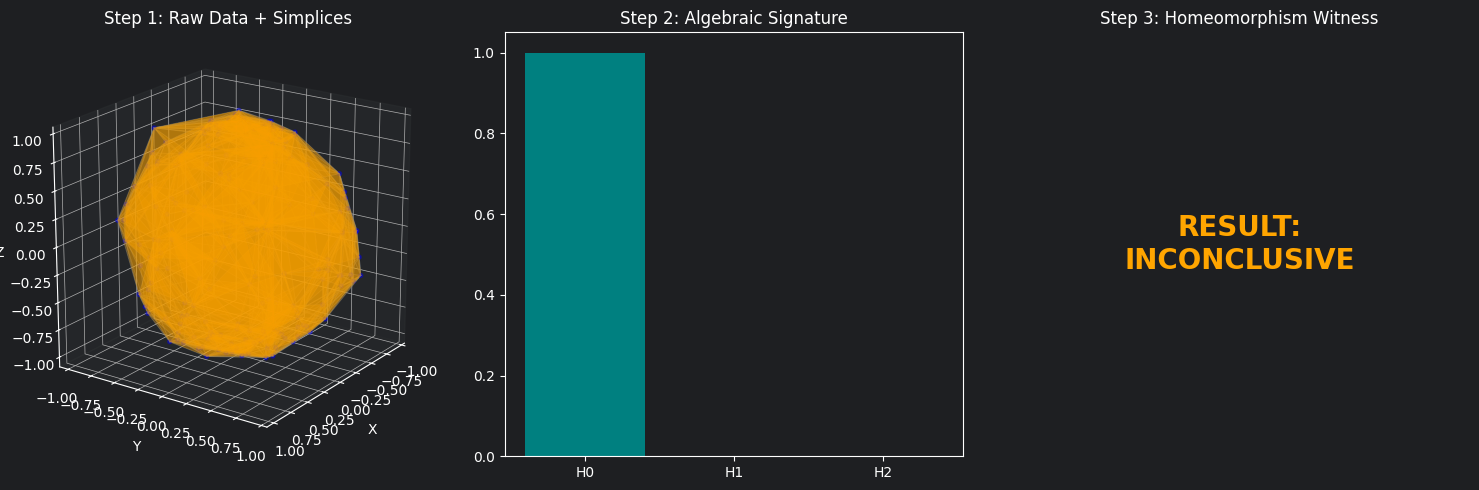

In [15]:
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(15, 5))

# 1. Geometry + simplex tree overlay
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(points[:, 0], points[:, 1], points[:, 2], s=8, color='blue', alpha=0.35)

edges = []
faces = []

for simplex, _ in st.get_filtration():
    if len(simplex) == 2:
        i, j = simplex
        p1, p2 = points[i], points[j]
        ax1.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            [p1[2], p2[2]],
            color='gray',
            linewidth=0.7,
            alpha=0.5,
        )
    elif len(simplex) == 3:
        i, j, k = simplex
        faces.append([points[i], points[j], points[k]])

if faces:
    poly = Poly3DCollection(
        faces,
        alpha=0.12,
        facecolor='orange',
        edgecolor='none'
    )
    ax1.add_collection3d(poly)

ax1.set_title('Step 1: Raw Data + Simplices')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.view_init(elev=20, azim=35)
ax1.set_box_aspect((1, 1, 1))

mins = points.min(axis=0)
maxs = points.max(axis=0)
centers = (mins + maxs) / 2
radius = np.max((maxs - mins) / 2)
ax1.set_xlim(centers[0] - radius, centers[0] + radius)
ax1.set_ylim(centers[1] - radius, centers[1] + radius)
ax1.set_zlim(centers[2] - radius, centers[2] + radius)

# 2. Invariants
ax2 = fig.add_subplot(132)
ax2.bar(['H0', 'H1', 'H2'], h_ranks, color='teal')
ax2.set_title('Step 2: Algebraic Signature')

# 3. Decision
ax3 = fig.add_subplot(133)
status_color = 'green' if witness_res.status == 'success' else 'orange'
ax3.text(
    0.5, 0.5,
    f'RESULT:\n{witness_res.status.upper()}',
    ha='center', va='center',
    fontsize=20, fontweight='bold',
    color=status_color
)
ax3.set_title('Step 3: Homeomorphism Witness')
ax3.axis('off')

plt.tight_layout()
plt.show()

## Capstone Summary Checklist
- [x] Ingested raw point cloud data.
- [x] Verified intrinsic dimension using Two-NN.
- [x] Constructed a simplicial model via Alpha/Rips filtrations.
- [x] Extracted exact homology and fundamental group data.
- [x] Produced a high-level `HomeomorphismWitness` certificate.

## Final Exercises
1. **The Noisy Torus**: Repeat the capstone workflow for a torus point cloud. Ensure you identify $\beta_1 = 2$.
2. **Exotic Search**: Build two 4D manifolds with the same intersection form but different Kirby-Siebenmann invariants. Does the capstone handle the failure?
3. **Large Scale**: Execute the pipeline for 5,000 points. Benchmark each stage (IDE, Complex, SNF).
4. **Certificate Export**: Write a function to export the capstone witness to a signed PDF or Markdown report.
5. **Real Data**: Download a 3D mesh from an online repository (e.g., Stanford Bunny) and run it through the 2D classification analyzer.

## Graduation: Next Steps
Congratulations! You have completed the `pipeline_v2` curriculum. You are now equipped to:
- Use **Exact Algebra** for rigorous topology.
- Leverage **Julia** for high-performance research.
- Integrate **TDA** with **Surgery Theory**.
- Build **Certified Classifications** for complex manifolds.

**Return to [README.md](../../README.md) for advanced API documentation.**
